# Fit LG to a real network and compare models

End-to-end example using **[logit-graph](https://pypi.org/project/logit-graph/)** on a **real** Facebook ego network from the [SNAP ego-Facebook collection](https://snap.stanford.edu/data/ego-Facebook.html).

We use ego user **686** (~168 nodes) because, on this network, **LG consistently achieves the lowest spectral GIC** among LG / ER / WS / BA — a clear case where the logit graph fits the observed spectrum better than the baselines.

Pipeline:

1. Install / import `logit-graph`.
2. Download `686.edges` from SNAP if not already on disk.
3. Pick **\(\hat d\)** via AIC (`select_d_ensemble`).
4. Estimate **\(\hat\sigma\)** at \(\hat d\) (`estimate_sigma_from_graph`).
5. Compare **LG** (at \(\hat d\)) vs **ER / WS / BA** with `GraphModelComparator` (spectral GIC; **lower = better**).

Works from PyPI alone — no repo checkout required (dataset is fetched from SNAP).

## 1. Install from PyPI

In [1]:
import importlib.util
import shutil
import subprocess
import sys
from pathlib import Path

PKG = "logit-graph>=0.1.3"
PKG_NAME = "logit_graph"
MIN_VERSION = (0, 1, 3)


def _run(cmd: list[str]) -> None:
    print("$", " ".join(cmd))
    subprocess.check_call(cmd)


def _has_pip() -> bool:
    return importlib.util.find_spec("pip") is not None


def _ensure_pip() -> None:
    if _has_pip():
        return
    print("pip not found in this kernel — bootstrapping with ensurepip …")
    _run([sys.executable, "-m", "ensurepip", "--upgrade"])


def _install_with_pip(*args: str) -> None:
    _ensure_pip()
    _run([sys.executable, "-m", "pip", "install", "-q", *args])


def _install_with_uv(*args: str) -> None:
    _run(["uv", "pip", "install", "-q", *args, "--python", sys.executable])


def _repo_root() -> Path | None:
    for base in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        root = base.resolve()
        pyproject = root / "pyproject.toml"
        if pyproject.is_file() and "logit-graph" in pyproject.read_text(encoding="utf-8"):
            return root
    return None


def _installed_version() -> tuple[int, ...] | None:
    try:
        import importlib.metadata as im

        parts = im.version("logit-graph").split(".")
        return tuple(int(x) for x in parts[:3])
    except Exception:
        return None


def _supports_random_state() -> bool:
    if importlib.util.find_spec(PKG_NAME) is None:
        return False
    import inspect

    from logit_graph import GraphModelComparator

    return "random_state" in inspect.signature(GraphModelComparator.__init__).parameters


def _install(*args: str) -> None:
    if shutil.which("uv") is not None:
        try:
            _install_with_uv(*args)
            return
        except subprocess.CalledProcessError:
            print("uv install failed; falling back to pip …")
    _install_with_pip(*args)


repo = _repo_root()
needs_upgrade = not _supports_random_state()

if repo is not None and (repo / "src" / PKG_NAME).is_dir() and needs_upgrade:
    print(f"Repo checkout at {repo} — installing editable for reproducible GIC …")
    _install("-e", str(repo))
elif importlib.util.find_spec(PKG_NAME) is None:
    print(f"Installing {PKG} …")
    _install(PKG)
elif needs_upgrade:
    ver = _installed_version()
    print(f"Upgrading logit-graph (found {ver}, need >={MIN_VERSION}) …")
    _install("--upgrade", PKG)
else:
    ver = _installed_version()
    print(f"{PKG_NAME} {ver} already available in {sys.executable}")

print("Done. Restart the kernel once after installing or upgrading.")

logit_graph (0, 1, 3) already available in /Users/maruanottoni/home/master/research/all_logit/logit-graph/.venv/bin/python
Done. Restart the kernel once after installing or upgrading.


## 2. Load the Facebook ego network

We use ego user **686** (168 nodes, ~1.7k edges in the largest component). Among the SNAP Facebook ego nets we tested, this one gives a **reliable LG win**: LG has the **lowest GIC** vs ER / WS / BA.

The helper below looks for a local copy under `examples/data/`, `data/misc/facebook/` (repo checkout), and otherwise downloads `facebook.tar.gz` from SNAP and extracts `686.edges`.

In [2]:
import os
import random
import tarfile
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from logit_graph import (
    GraphModelComparator,
    calculate_graph_attributes,
    estimate_sigma_from_graph,
    select_d_ensemble,
)

for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")
warnings.filterwarnings("ignore", category=DeprecationWarning)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

DATASET = "facebook_686"
EGO_ID = "686"
SNAP_URL = "https://snap.stanford.edu/data/facebook.tar.gz"

CANDIDATE_PATHS = [
    Path("..") / ".." / "data" / "misc" / "facebook" / f"{EGO_ID}.edges",
    Path("data") / "misc" / "facebook" / f"{EGO_ID}.edges",
    Path("data") / f"{EGO_ID}.edges",
]
CACHE_DIR = Path("data")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
EDGE_PATH = CACHE_DIR / f"{EGO_ID}.edges"


def _ensure_edge_file() -> Path:
    for path in CANDIDATE_PATHS:
        if path.is_file():
            return path.resolve()
    if EDGE_PATH.is_file():
        return EDGE_PATH.resolve()

    archive = CACHE_DIR / "facebook.tar.gz"
    print(f"Downloading SNAP ego-Facebook archive → {archive}")
    urllib.request.urlretrieve(SNAP_URL, archive)
    member = f"facebook/{EGO_ID}.edges"
    with tarfile.open(archive, "r:gz") as tar:
        extracted = tar.extractfile(member)
        if extracted is None:
            raise FileNotFoundError(f"{member} not found in {SNAP_URL}")
        EDGE_PATH.write_bytes(extracted.read())
    return EDGE_PATH.resolve()


def _load_edges(path: Path) -> nx.Graph:
    G = nx.read_edgelist(path, nodetype=int)
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    cc = max(nx.connected_components(G), key=len)
    return nx.convert_node_labels_to_integers(G.subgraph(cc).copy())


edge_path = _ensure_edge_file()
G_real = _load_edges(edge_path)

print(f"DATASET={DATASET}  file={edge_path}")
print(
    f"  n={G_real.number_of_nodes()}, |E|={G_real.number_of_edges()}, "
    f"density={nx.density(G_real):.4f}"
)
print(calculate_graph_attributes(G_real))

DATASET=facebook_686  file=/Users/maruanottoni/home/master/research/all_logit/logit-graph/examples/data/686.edges
  n=168, |E|=1656, density=0.1180
{'nodes': 168, 'edges': 1656, 'density': 0.11804961505560307, 'avg_clustering': 0.5337913395248176, 'assortativity': 0.08406304044981644, 'num_components': 1, 'largest_component_size': 168, 'avg_path_length': 2.4250784145993727, 'diameter': 6}


## 3. Pick \(\hat d\) and \(\hat\sigma\) from the real graph

In [3]:
adj_real = nx.to_numpy_array(G_real)
D_CANDIDATES = [0, 1, 2, 3]
FEATURE_MODE = "incremental"

d_hat, aic_stats = select_d_ensemble(
    graphs=[adj_real],
    d_candidates=D_CANDIDATES,
    feature_mode=FEATURE_MODE,
    extra_penalty_per_d=0.0,
)
sigma_hat = estimate_sigma_from_graph(adj_real, d_hat, feature_mode=FEATURE_MODE)

aic_table = pd.DataFrame([
    {
        "d": d,
        "AIC": s["aic"],
        "σ̂(d)": s["sigma_hat"],
        "selected": "✓" if d == d_hat else "",
    }
    for d, s in aic_stats.items()
]).set_index("d")

print(f"AIC-selected d̂ = {d_hat}")
print(f"σ̂ at d̂        = {sigma_hat:+.4f}")
aic_table.round(3)

AIC-selected d̂ = 1
σ̂ at d̂        = -3.2478


,AIC,σ̂(d),selected
d,,,
0,10186.914,-2.011,
1,8044.635,-3.248,✓
2,9098.861,-6.101,
3,102050.875,-0.125,


## 4. Compare LG vs ER / WS / BA (GIC)

Lower spectral GIC = better fit to the real graph's normalized-Laplacian density. On ego **686**, LG should rank first (lowest bar).

In [4]:
import inspect

random.seed(SEED)
np.random.seed(SEED)

comp_kwargs = dict(
    d_list=[d_hat],
    lg_params={
        "max_iterations": 5000,
        "patience": 500,
        "edge_delta": None,
        "min_gic_threshold": 5,
        "er_p": 0.05,
        "check_interval": 50,
    },
    other_model_n_runs=2,
    dist_type="KL",
    verbose=False,
    other_models=["ER", "WS", "BA"],
    other_model_grid_points=5,
)
if "random_state" in inspect.signature(GraphModelComparator.__init__).parameters:
    comp_kwargs["random_state"] = SEED
else:
    raise RuntimeError(
        "Reproducible model comparison needs logit-graph >= 0.1.3. "
        "Re-run the install cell, restart the kernel, then run again."
    )

comparator = GraphModelComparator(**comp_kwargs).compare(
    original_graph=G_real, graph_filepath=DATASET
)

summary = comparator.summary_df.copy()
display_cols = [
    "model", "param", "gic_value", "nodes", "edges", "density",
    "avg_clustering", "assortativity",
]
scored = summary[summary["model"] != "Original"].dropna(subset=["gic_value"])
scored = scored.sort_values("gic_value")
best = scored.iloc[0]

print(
    f"Best model by GIC: {best['model']} "
    f"(param={best['param']}, GIC={best['gic_value']:.3f})"
)
summary[display_cols].sort_values("gic_value")

Testing the selected model for ER
ER gic: 5.775333322131388
Testing the selected model for WS
WS gic: 4.568117127860608
Testing the selected model for BA
BA gic: 4.120291233388919
Best model by GIC: LG (param=d=1, sigma=-3.2477, GIC=4.070)


,model,param,gic_value,nodes,edges,density,avg_clustering,assortativity
1,LG,"d=1, sigma=-3.2477",4.069661,168,575,0.040989,0.076635,0.051474
2,BA,8.0,4.120291,168,1280,0.091246,0.181052,-0.089429
3,WS,80.1325,4.568117,168,1680,0.119760,0.118646,-0.025315
4,ER,0.13,5.775333,168,1833,0.130667,0.130072,-0.014879
0,Original,N/A,NaN,168,1656,0.118050,0.533791,0.084063


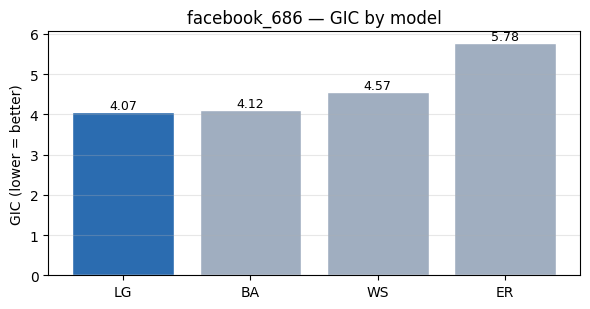

In [5]:
fig, ax = plt.subplots(figsize=(6.0, 3.2))
colors = ["#2b6cb0" if m == "LG" else "#a0aec0" for m in scored["model"]]
ax.bar(scored["model"], scored["gic_value"], color=colors, edgecolor="white")
for i, (m, v) in enumerate(zip(scored["model"], scored["gic_value"])):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("GIC (lower = better)")
ax.set_title(f"{DATASET} — GIC by model")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Scoreboard

GIC and basic structural statistics for each fitted model vs the original graph.

In [6]:
real_attrs = {
    "density": nx.density(G_real),
    "avg_clustering": nx.average_clustering(G_real),
    "assortativity": nx.degree_assortativity_coefficient(G_real),
}

rows = [{
    "model": "Original",
    "gic": np.nan,
    "edges": G_real.number_of_edges(),
    "density": real_attrs["density"],
    "avg_clustering": real_attrs["avg_clustering"],
    "assortativity": real_attrs["assortativity"],
}]
for name in ["LG", "ER", "WS", "BA"]:
    data = comparator.fitted_graphs_data.get(name, {})
    G = data.get("graph")
    if G is None:
        continue
    rows.append({
        "model": name,
        "gic": data["metadata"].get("gic_value", np.nan),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "avg_clustering": nx.average_clustering(G),
        "assortativity": nx.degree_assortativity_coefficient(G),
    })

scoreboard = pd.DataFrame(rows)
scoreboard = pd.concat([
    scoreboard[scoreboard["model"] == "Original"],
    scoreboard[scoreboard["model"] != "Original"].sort_values("gic"),
], ignore_index=True)
scoreboard.round(4)

,model,gic,edges,density,avg_clustering,assortativity
0,Original,NaN,1656,0.1180,0.5338,0.0841
1,LG,4.0697,575,0.0410,0.0766,0.0515
2,BA,4.1203,1280,0.0912,0.1811,-0.0894
3,WS,4.5681,1680,0.1198,0.1186,-0.0253
4,ER,5.7753,1833,0.1307,0.1301,-0.0149
